In [2]:
import pandas as pd
df = pd.read_csv("hotel_bookings.csv")
print(df.head())
print("Shape of dataframe",df.shape)
print("*"*60)
print("Information of dataframe",df.info)
print("*"*60)
print("Description of the columns",df.describe())
print("*"*60)
print("Data type of the dataframe",df.dtypes)

df["is_canceled"].value_counts() #and in this 0 denotes that booking was not cancelled and vice versa

y=df["is_canceled"]
x = df.drop(columns=["is_canceled"])

# We are differentiating the numeric columns and categorical columns
numeric_columns = x.select_dtypes(include=["int64","float64"]).columns
print("*"*60)
print(numeric_columns)

print("*"*60)
categorical_cols = x.select_dtypes(include=["object","str"]).columns
print(categorical_cols)

          hotel  is_canceled  lead_time  arrival_date_year arrival_date_month  \
0  Resort Hotel            0        342               2015               July   
1  Resort Hotel            0        737               2015               July   
2  Resort Hotel            0          7               2015               July   
3  Resort Hotel            0         13               2015               July   
4  Resort Hotel            0         14               2015               July   

   arrival_date_week_number  arrival_date_day_of_month  \
0                        27                          1   
1                        27                          1   
2                        27                          1   
3                        27                          1   
4                        27                          1   

   stays_in_weekend_nights  stays_in_week_nights  adults  ...  deposit_type  \
0                        0                     0       2  ...    No Deposit   
1     

Missing Value Summary:


,Missing Count,Missing Percentage
company,112593,94.306893
agent,16340,13.686238
country,488,0.408744
children,4,0.003350
arrival_date_month,0,0.000000
arrival_date_week_number,0,0.000000
hotel,0,0.000000
is_canceled,0,0.000000
stays_in_weekend_nights,0,0.000000
arrival_date_day_of_month,0,0.000000


Columns with more than 50% missing values:


,Missing Count,Missing Percentage
company,112593,94.306893



Shape after handling high-missingness columns:
(119390, 31)

Leakage columns removed:
['reservation_status', 'reservation_status_date']

Shape after removing leakage columns:
(119390, 29)


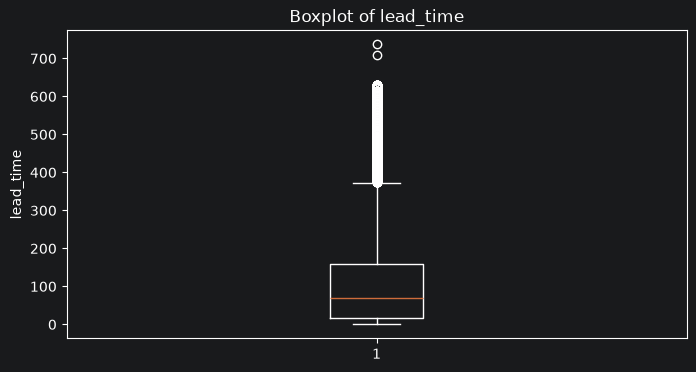

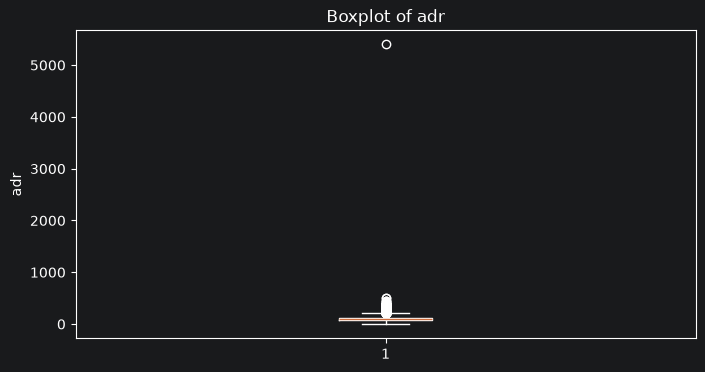

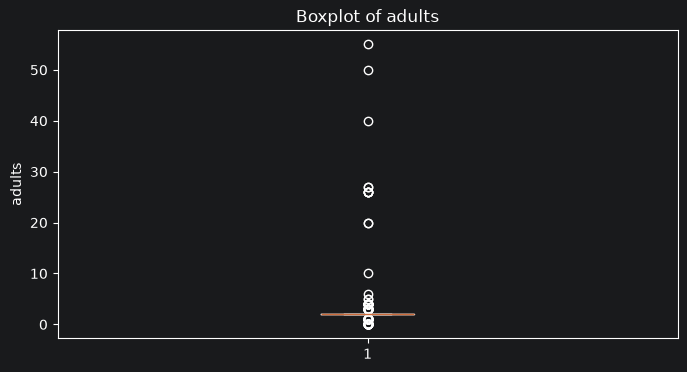

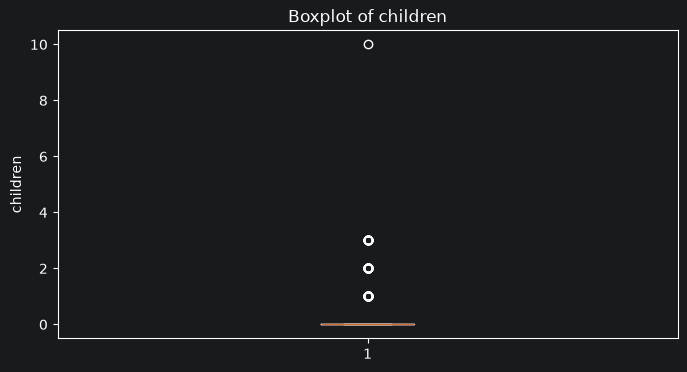

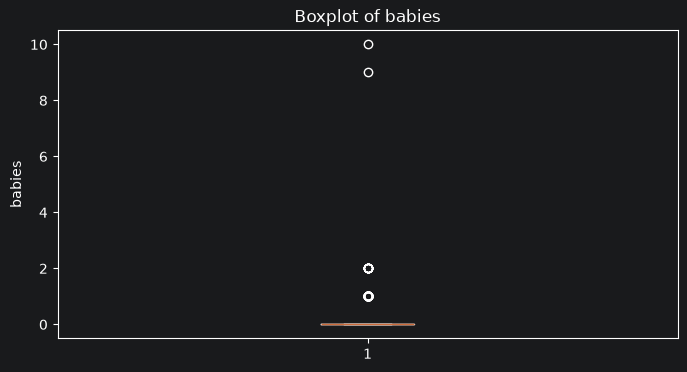


lead_time
Q1: 18.0
Q3: 160.0
IQR: 142.0
Lower Bound: -408.0
Upper Bound: 586.0

adr
Q1: 69.29
Q3: 126.0
IQR: 56.709999999999994
Lower Bound: -100.83999999999999
Upper Bound: 296.13

adults
Q1: 2.0
Q3: 2.0
IQR: 0.0
Lower Bound: 2.0
Upper Bound: 2.0

children
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0

babies
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower Bound: 0.0
Upper Bound: 0.0

Outlier Removal Summary
-----------------------
Rows before outlier removal: 119390
Rows after outlier removal: 81325
Rows removed: 38065

Cleaned dataset saved as 'cleaned_hotel_bookings.csv'


In [3]:
missing_count = df.isna().sum()
missing_percentage = (missing_count / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing Percentage": missing_percentage
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

print("Missing Value Summary:")
display(missing_summary)

high_missing = missing_summary[
    missing_summary["Missing Percentage"] > 50
]

print("Columns with more than 50% missing values:")
display(high_missing)

if "company" in df.columns:
    df = df.drop(columns=["company"])

print("\nShape after handling high-missingness columns:")
print(df.shape)

leakage_columns = [
    "reservation_status",
    "reservation_status_date"
]

existing_leakage_columns = [
    column
    for column in leakage_columns
    if column in df.columns
]

df = df.drop(
    columns=existing_leakage_columns
)

print("\nLeakage columns removed:")
print(existing_leakage_columns)

print("\nShape after removing leakage columns:")
print(df.shape)

import matplotlib.pyplot as plt

outlier_columns = [
    "lead_time",
    "adr",
    "adults",
    "children",
    "babies"
]

outlier_columns = [
    column
    for column in outlier_columns
    if column in df.columns
]

for column in outlier_columns:

    plt.figure(figsize=(8, 4))

    plt.boxplot(
        df[column].dropna()
    )

    plt.title(
        f"Boxplot of {column}"
    )

    plt.ylabel(column)

    plt.show()

outlier_bounds = {}

for column in outlier_columns:

    Q1 = df[column].quantile(0.25)

    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 3 * IQR

    upper_bound = Q3 + 3 * IQR

    outlier_bounds[column] = (
        lower_bound,
        upper_bound
    )

    print(f"\n{column}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)


rows_before = len(df)

outlier_mask = pd.Series(
    False,
    index=df.index
)

for column in outlier_columns:
    lower_bound, upper_bound = outlier_bounds[column]
    column_outliers = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    )

    outlier_mask = (
        outlier_mask |
        column_outliers
    )

df = df[~outlier_mask].copy()

rows_after = len(df)

rows_removed = rows_before - rows_after


print("\nOutlier Removal Summary")
print("-----------------------")

print(
    "Rows before outlier removal:",
    rows_before
)

print(
    "Rows after outlier removal:",
    rows_after
)

print(
    "Rows removed:",
    rows_removed
)


df.to_csv(
    "cleaned_hotel_bookings.csv",
    index=False
)

print(
    "\nCleaned dataset saved as "
    "'cleaned_hotel_bookings.csv'"
)


In [5]:
# ============================================================
# TASK 3
# Create Two Preprocessing Pipelines
# ============================================================

y = df["is_canceled"]

X = df.drop(
    columns=["is_canceled"]
)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

numerical_cols = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X.select_dtypes(
    include=["object"]
).columns

print("\nNumerical Columns:")
print(list(numerical_cols))

print("\nCategorical Columns:")
print(list(categorical_cols))

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("\nTrain-Test Split")
print("----------------")

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import (
    KNNImputer,
    SimpleImputer
)
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    OneHotEncoder
)
categorical_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="most_frequent"
        )
    ),
    (
        "encoder",
        OneHotEncoder(
            handle_unknown="ignore"
        )
    )
])
numeric_pipeline_A = Pipeline([
    (
        "imputer",
        KNNImputer(
            n_neighbors=5
        )
    ),

    (
        "scaler",
        StandardScaler()
    )
])

preprocessor_A = ColumnTransformer([

    (
        "num",
        numeric_pipeline_A,
        numerical_cols
    ),

    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])


pipeline_A = Pipeline([

    (
        "preprocessor",
        preprocessor_A
    )
])

numeric_pipeline_B = Pipeline([

    (
        "imputer",
        KNNImputer(
            n_neighbors=5
        )
    ),

    (
        "scaler",
        MinMaxScaler()
    )
])
preprocessor_B = ColumnTransformer([
    (
        "num",
        numeric_pipeline_B,
        numerical_cols
    ),
    (
        "cat",
        categorical_pipeline,
        categorical_cols
    )
])
pipeline_B = Pipeline([
    (
        "preprocessor",
        preprocessor_B
    )
])
print("\nPipeline A:")
print(pipeline_A)

print("\nPipeline B:")
print(pipeline_B)


X shape: (81325, 28)
y shape: (81325,)

Numerical Columns:
['lead_time', 'arrival_date_year', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'booking_changes', 'agent', 'days_in_waiting_list', 'adr', 'required_car_parking_spaces', 'total_of_special_requests']

Categorical Columns:
['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type', 'deposit_type', 'customer_type']

Train-Test Split
----------------
X_train: (65060, 28)
X_test: (16265, 28)
y_train: (65060,)
y_test: (16265,)

Pipeline A:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   KNNImputer()),

C:\Users\Admin\AppData\Local\Temp\ipykernel_13184\2201141726.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(


In [7]:
# ============================================================
# PART B - TASK 4
# ============================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
logistic_pipeline_A = Pipeline([
    (
        "preprocessor",
        preprocessor_A
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])
logistic_pipeline_B = Pipeline([
    (
        "preprocessor",
        preprocessor_B
    ),
    (
        "model",
        LogisticRegression(
            max_iter=1000
        )
    )
])
decision_tree_pipeline_A = Pipeline([
    (
        "preprocessor",
        preprocessor_A
    ),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])
decision_tree_pipeline_B = Pipeline([
    (
        "preprocessor",
        preprocessor_B
    ),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])
print(
    "Training Logistic Regression + Pipeline A..."
)
logistic_pipeline_A.fit(
    X_train,
    y_train
)
print("Completed.")

print(
    "\nTraining Logistic Regression + Pipeline B..."
)
logistic_pipeline_B.fit(
    X_train,
    y_train
)
print("Completed.")
print(
    "\nTraining Decision Tree + Pipeline A..."
)
decision_tree_pipeline_A.fit(
    X_train,
    y_train
)
print("Completed.")
print("\nTraining Decision Tree + Pipeline B")

decision_tree_pipeline_B.fit(
    X_train,
    y_train
)

print("Completed.")

print("\n==============================================")
print("ALL FOUR MODEL-PIPELINE COMBINATIONS TRAINED")
print("==============================================")

print("1. Logistic Regression + StandardScaler")
print("2. Logistic Regression + MinMaxScaler")
print("3. Decision Tree + StandardScaler")
print("4. Decision Tree + MinMaxScaler")


Training Logistic Regression + Pipeline A...
Completed.

Training Logistic Regression + Pipeline B...
Completed.

Training Decision Tree + Pipeline A...
Completed.

Training Decision Tree + Pipeline B...
Completed.

ALL FOUR MODEL-PIPELINE COMBINATIONS TRAINED
1. Logistic Regression + StandardScaler
2. Logistic Regression + MinMaxScaler
3. Decision Tree + StandardScaler
4. Decision Tree + MinMaxScaler



FINAL MODEL COMPARISON TABLE


,Experiment,Training Accuracy,Testing Accuracy,Precision,Recall,F1-Score,Train-Test Difference
0,Logistic Regression + StandardScaler,0.8179,0.8194,0.8225,0.6946,0.7531,-0.0016
1,Logistic Regression + MinMaxScaler,0.8152,0.8157,0.8173,0.6895,0.7480,-0.0005
2,Decision Tree + StandardScaler,0.9964,0.8615,0.8240,0.8276,0.8258,0.1348
3,Decision Tree + MinMaxScaler,0.9964,0.8611,0.8229,0.8279,0.8254,0.1353



Comparison table saved as 'model_comparison.csv'

Best Logistic Regression: Logistic Regression + StandardScaler
Best Decision Tree: Decision Tree + StandardScaler

Confusion Matrix - Best Logistic Regression:
[[8848  967]
 [1970 4480]]


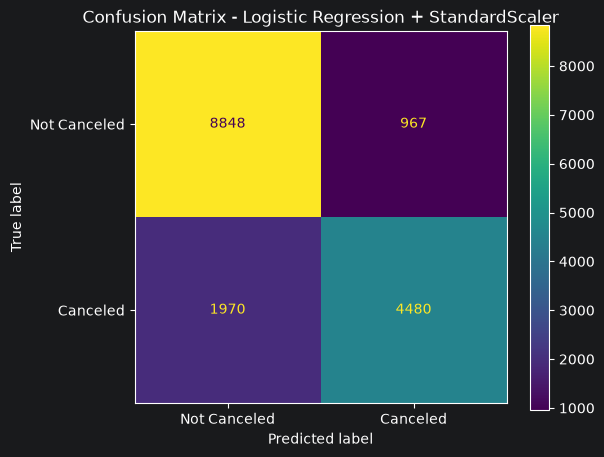


Confusion Matrix - Best Decision Tree:
[[8675 1140]
 [1112 5338]]


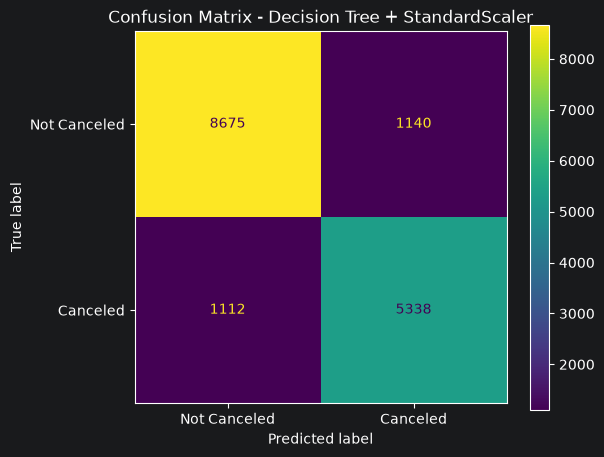


OVERFITTING ANALYSIS
Logistic Regression + StandardScaler: -0.0016
Logistic Regression + MinMaxScaler: -0.0005
Decision Tree + StandardScaler: 0.1348
Decision Tree + MinMaxScaler: 0.1353


In [9]:
# ============================================================
# TASK 5
# Evaluate and Compare the Four Results
# ============================================================
import os
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

experiments = {
    "Logistic Regression + StandardScaler":
        logistic_pipeline_A,

    "Logistic Regression + MinMaxScaler":
        logistic_pipeline_B,

    "Decision Tree + StandardScaler":
        decision_tree_pipeline_A,

    "Decision Tree + MinMaxScaler":
        decision_tree_pipeline_B
}
results = []
for name, model in experiments.items():
    # Training predictions
    y_train_pred = model.predict(
        X_train
    )
    # Testing predictions
    y_test_pred = model.predict(
        X_test
    )
    # Training accuracy
    train_accuracy = accuracy_score(
        y_train,
        y_train_pred
    )
    # Testing accuracy
    test_accuracy = accuracy_score(
        y_test,
        y_test_pred
    )
    # Precision
    precision = precision_score(
        y_test,
        y_test_pred,
        zero_division=0
    )
    # Recall
    recall = recall_score(
        y_test,
        y_test_pred,
        zero_division=0
    )
    # F1-score
    f1 = f1_score(
        y_test,
        y_test_pred,
        zero_division=0
    )

    # Train-test difference
    train_test_difference = (
        train_accuracy -
        test_accuracy
    )
    results.append({

        "Experiment": name,

        "Training Accuracy":
            train_accuracy,

        "Testing Accuracy":
            test_accuracy,

        "Precision":
            precision,

        "Recall":
            recall,

        "F1-Score":
            f1,

        "Train-Test Difference":
            train_test_difference
    })
comparison_table = pd.DataFrame(
    results
)

metric_columns = [
    "Training Accuracy",
    "Testing Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "Train-Test Difference"
]

comparison_table[
    metric_columns
] = comparison_table[
    metric_columns
].round(4)


print("\nFINAL MODEL COMPARISON TABLE")
print("============================")

display(
    comparison_table
)

comparison_table.to_csv(
    "model_comparison.csv",
    index=False
)

print(
    "\nComparison table saved as "
    "'model_comparison.csv'"
)

logistic_results = comparison_table[
    comparison_table["Experiment"].str.contains(
        "Logistic Regression"
    )
]

best_logistic_row = logistic_results.loc[
    logistic_results["F1-Score"].idxmax()
]

best_logistic_name = (
    best_logistic_row["Experiment"]
)

best_logistic_model = experiments[
    best_logistic_name
]

tree_results = comparison_table[
    comparison_table["Experiment"].str.contains(
        "Decision Tree"
    )
]

best_tree_row = tree_results.loc[
    tree_results["F1-Score"].idxmax()
]

best_tree_name = (
    best_tree_row["Experiment"]
)

best_tree_model = experiments[
    best_tree_name
]


print(
    "\nBest Logistic Regression:",
    best_logistic_name
)

print(
    "Best Decision Tree:",
    best_tree_name
)

y_pred_logistic = best_logistic_model.predict(
    X_test
)

cm_logistic = confusion_matrix(
    y_test,
    y_pred_logistic
)

print(
    "\nConfusion Matrix - Best Logistic Regression:"
)
print(cm_logistic)
os.makedirs(
    "figures",
    exist_ok=True
)
fig, ax = plt.subplots(
    figsize=(6, 5)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic,
    display_labels=[
        "Not Canceled",
        "Canceled"
    ]
)
disp.plot(
    ax=ax
)
ax.set_title(
    f"Confusion Matrix - {best_logistic_name}"
)
fig.savefig(
    "figures/confusion_matrix_logistic.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()
plt.close(fig)
y_pred_tree = best_tree_model.predict(
    X_test
)
cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)
print(
    "\nConfusion Matrix - Best Decision Tree:"
)
print(cm_tree)
fig, ax = plt.subplots(
    figsize=(6, 5)
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_tree,
    display_labels=[
        "Not Canceled",
        "Canceled"
    ]
)
disp.plot(
    ax=ax
)
ax.set_title(
    f"Confusion Matrix - {best_tree_name}"
)
fig.savefig(
    "figures/confusion_matrix_decision_tree.png",
    bbox_inches="tight",
    dpi=300
)
plt.show()
plt.close(fig)
print("\nOVERFITTING ANALYSIS")
print("====================")

for _, row in comparison_table.iterrows():

    difference = row[
        "Train-Test Difference"
    ]

    print(
        f"{row['Experiment']}: "
        f"{difference:.4f}"
    )


In [10]:

# ============================================================
# TASK 6
# Final Observations
# ============================================================
best_overall_row = comparison_table.loc[
    comparison_table["F1-Score"].idxmax()
]
best_overall_name = (
    best_overall_row["Experiment"]
)
print("\nBEST OVERALL MODEL")
print("==================")
print(best_overall_name)
print(
    "Testing Accuracy:",
    best_overall_row["Testing Accuracy"]
)
print(
    "Precision:",
    best_overall_row["Precision"]
)
print(
    "Recall:",
    best_overall_row["Recall"]
)
print(
    "F1-Score:",
    best_overall_row["F1-Score"]
)
logistic_standard = comparison_table[
    comparison_table["Experiment"] ==
    "Logistic Regression + StandardScaler"
].iloc[0]
logistic_minmax = comparison_table[
    comparison_table["Experiment"] ==
    "Logistic Regression + MinMaxScaler"
].iloc[0]
logistic_f1_difference = (
    logistic_standard["F1-Score"] -
    logistic_minmax["F1-Score"]
)
print(
    "\nLOGISTIC REGRESSION SCALING COMPARISON"
)
print(
    "StandardScaler F1:",
    logistic_standard["F1-Score"]
)
print(
    "MinMaxScaler F1:",
    logistic_minmax["F1-Score"]
)
print(
    "F1 difference:",
    round(
        logistic_f1_difference,
        4
    )
)
tree_standard = comparison_table[
    comparison_table["Experiment"] ==
    "Decision Tree + StandardScaler"
].iloc[0]
tree_minmax = comparison_table[
    comparison_table["Experiment"] ==
    "Decision Tree + MinMaxScaler"
].iloc[0]
tree_f1_difference = (
    tree_standard["F1-Score"] -
    tree_minmax["F1-Score"]
)
print(
    "\nDECISION TREE SCALING COMPARISON"
)
print(
    "StandardScaler F1:",
    tree_standard["F1-Score"]
)
print(
    "MinMaxScaler F1:",
    tree_minmax["F1-Score"]
)
print(
    "F1 difference:",
    round(
        tree_f1_difference,
        4
    )
)
print("\nFINAL OBSERVATIONS")
print(
    f"1. The best overall model-pipeline combination "
    f"is {best_overall_name}, based on the highest "
    f"F1-score of {best_overall_row['F1-Score']:.4f}."
)
if abs(logistic_f1_difference) < 0.01:
    print(
        "2. StandardScaler and MinMaxScaler produce "
        "very similar Logistic Regression F1-scores, "
        "so the choice of scaling method has only a "
        "small effect in this experiment."
    )
elif logistic_f1_difference > 0:
    print(
        "2. StandardScaler gives better Logistic Regression "
        "performance than MinMaxScaler based on F1-score."
    )
else:
    print(
        "2. MinMaxScaler gives better Logistic Regression "
        "performance than StandardScaler based on F1-score."
    )
if abs(tree_f1_difference) < 0.01:
    print(
        "3. The Decision Tree results are very similar "
        "with StandardScaler and MinMaxScaler, indicating "
        "that scaling does not make a major difference."
    )
else:
    print(
        "3. The Decision Tree shows some difference between "
        "the two scaling methods, although tree-based models "
        "are generally less sensitive to feature scaling.")
largest_gap = comparison_table.loc[
    comparison_table[
        "Train-Test Difference"
    ].idxmax()
]

print(
    f"4. {largest_gap['Experiment']} has the largest "
    f"train-test accuracy difference of "
    f"{largest_gap['Train-Test Difference']:.4f}, "
    f"suggesting the greatest potential for overfitting."
)
highest_recall_row = comparison_table.loc[
    comparison_table["Recall"].idxmax()
]
print(
    f"5. {highest_recall_row['Experiment']} achieves the "
    f"highest recall of "
    f"{highest_recall_row['Recall']:.4f}, indicating that "
    f"it identifies the largest proportion of actual "
    f"canceled bookings among the four experiments."
)



BEST OVERALL MODEL
Decision Tree + StandardScaler
Testing Accuracy: 0.8615
Precision: 0.824
Recall: 0.8276
F1-Score: 0.8258

LOGISTIC REGRESSION SCALING COMPARISON
StandardScaler F1: 0.7531
MinMaxScaler F1: 0.748
F1 difference: 0.0051

DECISION TREE SCALING COMPARISON
StandardScaler F1: 0.8258
MinMaxScaler F1: 0.8254
F1 difference: 0.0004

FINAL OBSERVATIONS
1. The best overall model-pipeline combination is Decision Tree + StandardScaler, based on the highest F1-score of 0.8258.
2. StandardScaler and MinMaxScaler produce very similar Logistic Regression F1-scores, so the choice of scaling method has only a small effect in this experiment.
3. The Decision Tree results are very similar with StandardScaler and MinMaxScaler, indicating that scaling does not make a major difference.
4. Decision Tree + MinMaxScaler has the largest train-test accuracy difference of 0.1353, suggesting the greatest potential for overfitting.
5. Decision Tree + MinMaxScaler achieves the highest recall of 0.8279